<a href="https://colab.research.google.com/github/chandiki/Notion-SentimentAnalysis/blob/main/05_Notion_Review_BoW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notion Google Play Review Bag of Words**


## **⚙️ Process Description**

| Step | Task | Tool | Description |
|------|------|------|-------------|
| 1 | Load preprocessed data | pandas | Load cleaned dataset containing preprocessed review text for analysis |
| 2 | Explore cleaned text | pandas | Inspect data quality, missing values, and word count distribution |
| 3 | Fit Bag of Words (CountVectorizer) | scikit-learn | Convert text into numerical representation using word frequency (BoW model) |
| 4 | Inspect vocabulary & matrix | pandas, scikit-learn | Check extracted vocabulary and sparse document-term matrix shape |
| 5 | Analyze term frequency | numpy, pandas | Aggregate word occurrences across all documents to find most frequent terms |
| 6 | Visualize top terms | matplotlib | Plot most frequent words using bar chart visualization |
| 7 | Sentiment-based BoW analysis | scikit-learn, pandas | Compare word frequency distribution across sentiment classes |
| 8 | Regex-based sentiment signals | re, pandas | Extract sentiment cues using rule-based keyword matching |
| 9 | Export BoW artifacts | scipy, pickle, pandas | Save BoW matrix, vocabulary, and vectorizer for reuse in modeling |

### **Setup & Data Loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import save_npz
import pickle
import re

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Tugas Individu/Dataset/notion_reviews_sentiment.csv')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: 20,758 rows x 11 columns


,content,score,at,thumbsUpCount,replyContent,final_text,final_tokens,sentiment_polarity,sentiment_subjectivity,sentiment_label,year
0,"had a payment issue, the SAV solved it quickly.",5,2026-04-29 16:35:03,0,NaN,payment issu solv quickli,"['payment', 'issu', 'solv', 'quickli']",0.000000,0.000000,neutral,2026
1,"Using Notion on a high-end phone, but it keeps...",1,2026-04-29 14:15:07,0,NaN,use notion highend phone keep get laggier upda...,"['use', 'notion', 'highend', 'phone', 'keep', ...",-0.110000,0.415000,negative,2026
2,"I loved this app, but my documents keep going ...",3,2026-04-29 10:38:49,0,NaN,love app document keep go miss,"['love', 'app', 'document', 'keep', 'go', 'miss']",0.500000,0.600000,positive,2026
3,powerful (All in 1). but new ke liye itna jada...,1,2026-04-29 09:22:59,0,NaN,power new ke hard hai use bad ui ux,"['power', 'new', 'ke', 'hard', 'hai', 'use', '...",-0.285101,0.554293,negative,2026
4,Very bad mobile experience. Everything is so s...,1,2026-04-28 20:29:03,0,NaN,bad mobil experi everyth slow hard actual save...,"['bad', 'mobil', 'experi', 'everyth', 'slow', ...",-0.322917,0.427083,negative,2026


### **Explore Cleaned Text**

In [4]:
df = df.dropna(subset=['final_text'])
df = df[df['final_text'].str.strip() != '']
df = df.reset_index(drop=True)

df['word_count'] = df['final_text'].apply(lambda x: len(str(x).split()))

print(df['word_count'].describe())

count    20758.000000
mean        12.534204
std         11.990468
min          1.000000
25%          4.000000
50%          8.000000
75%         17.000000
max        193.000000
Name: word_count, dtype: float64


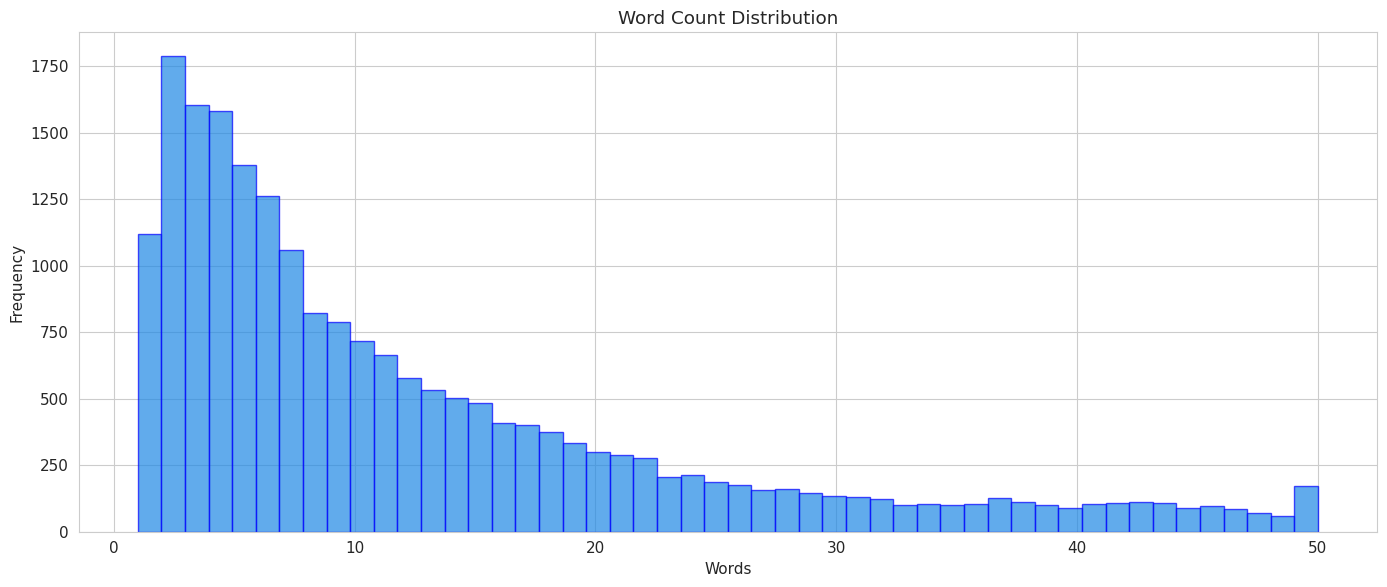

In [32]:
df['word_count'].clip(upper=50).hist(
    bins=50,
    edgecolor='blue',
    alpha=0.7,
    color='#1E88E5'
)

plt.title('Word Count Distribution')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### **Fit Bag of Words (CountVectorizer)**

In [6]:
bow_vectorizer = CountVectorizer(
    analyzer='word',
    token_pattern=r'\b\w+\b',
    min_df=2,
    max_df=0.95
)

bow_matrix = bow_vectorizer.fit_transform(df['final_text'])

print('BoW Shape:', bow_matrix.shape)
print('Vocabulary size:', len(bow_vectorizer.get_feature_names_out()))

BoW Shape: (20758, 4071)
Vocabulary size: 4071


### **Inspect Vocabulary & Frequency**

In [7]:
vocab = bow_vectorizer.get_feature_names_out()

term_freq = np.asarray(bow_matrix.sum(axis=0)).flatten()

df_freq = pd.DataFrame({
    'term': vocab,
    'frequency': term_freq
}).sort_values('frequency', ascending=False)

df_freq.head(30)

,term,frequency
188,app,13981
3684,use,6058
2284,notion,4473
2274,note,3601
3844,work,2782
1430,great,2566
1971,love,2560
1928,like,2259
348,best,2187
1396,good,2176


### **BoW by Sentiment**

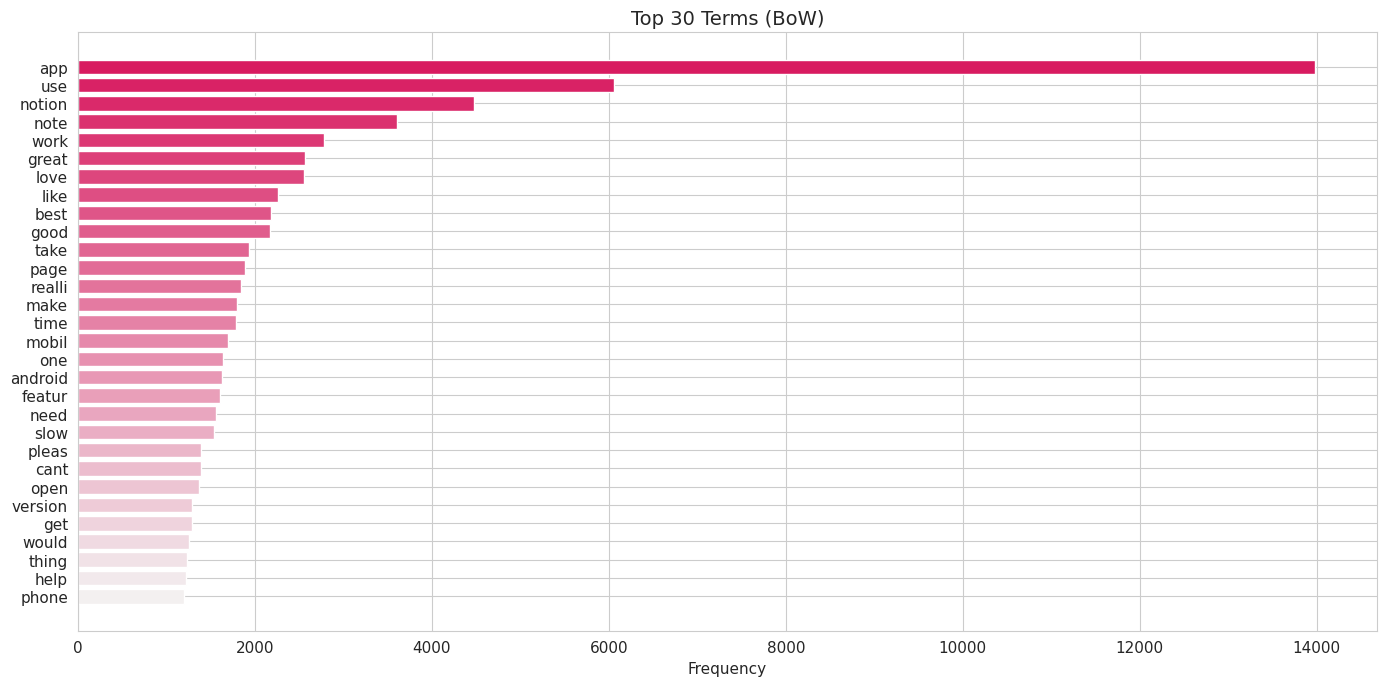

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

top_n = 30
top_terms = df_freq.head(top_n)

# gradient pink: dark -> light (atas ke bawah)
colors = sns.light_palette("#D81B60", n_colors=top_n, reverse=False)

plt.figure(figsize=(14, 7))

plt.barh(
    top_terms['term'][::-1],
    top_terms['frequency'][::-1],
    color=colors
)

plt.title('Top 30 Terms (BoW)', fontsize=14)
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

### **Regex Sentiment Signals**

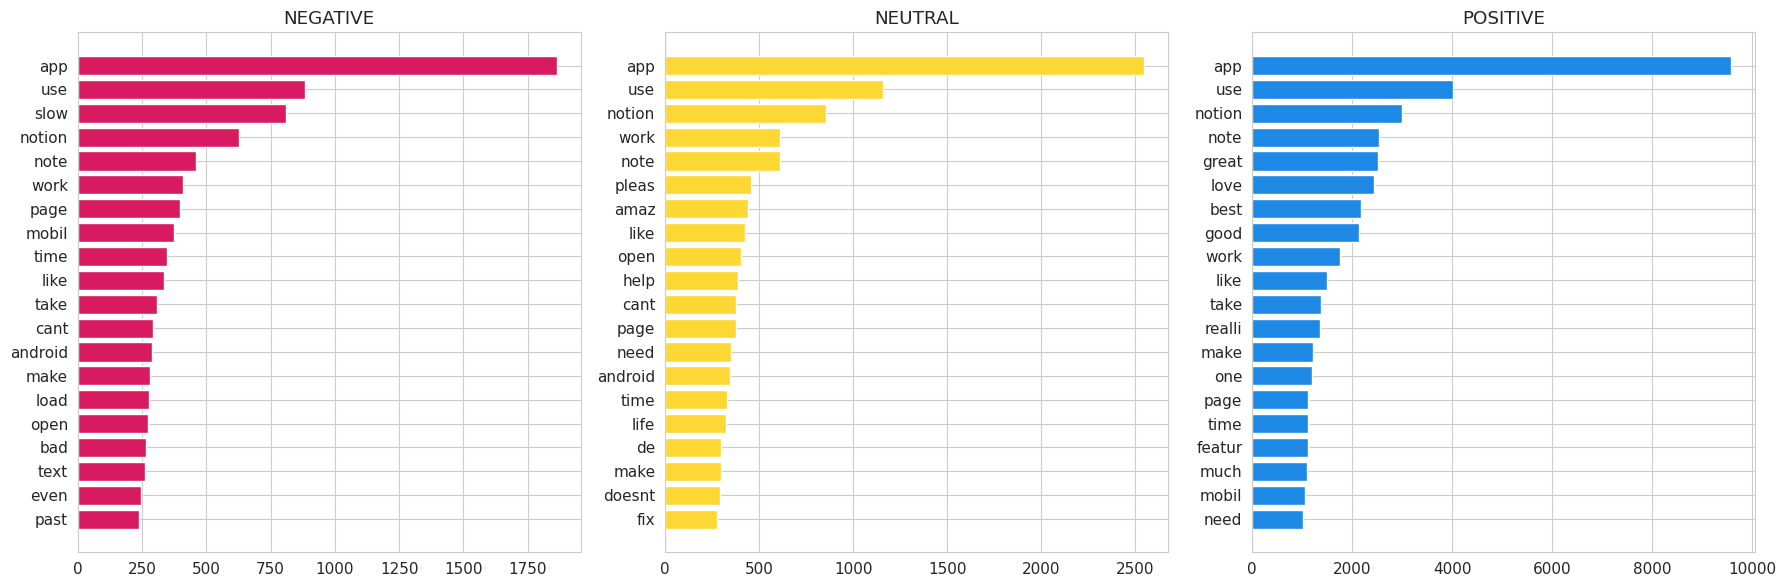

In [31]:
import numpy as np
import matplotlib.pyplot as plt

df = df.reset_index(drop=True)

sentiments = df['sentiment_label'].values
unique_sentiments = np.unique(sentiments)

colors = ['#D81B60', '#FDD835', '#1E88E5']  # pink, yellow, blue

fig, axes = plt.subplots(1, len(unique_sentiments), figsize=(18, 6))

if len(unique_sentiments) == 1:
    axes = [axes]

for ax, s, color in zip(axes, unique_sentiments, colors):

    mask = (sentiments == s)
    subset = bow_matrix[mask]

    freq = np.asarray(subset.sum(axis=0)).flatten()
    top_idx = freq.argsort()[::-1][:20]

    ax.barh(
        vocab[top_idx][::-1],
        freq[top_idx][::-1],
        color=color
    )

    ax.set_title(str(s).upper())

plt.tight_layout()
plt.show()

In [36]:
term_freq = np.asarray(bow_matrix.sum(axis=0)).flatten()
top_20_idx = term_freq.argsort()[::-1][:20]
top_20_terms = vocab[top_20_idx]

preview_df = pd.DataFrame(
    bow_matrix[:10, top_20_idx].toarray(),
    columns=top_20_terms
)
print('BoW Matrix Preview (10 rows x top 20 frequent terms):')
preview_df

BoW Matrix Preview (10 rows x top 20 frequent terms):


,app,use,notion,note,work,great,love,like,best,good,take,page,realli,make,time,mobil,one,android,featur,need
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,2,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
2,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### **Result**

In [34]:
import re

positive_patterns = [
    r'\b(good|great|excellent|amazing|awesome|nice|love|like|satisfied|happy|fast|easy|smooth|helpful)\b',
    r'\b(thank you|thanks)\b',
    r'\b(recommend|recommended)\b'
]

negative_patterns = [
    r'\b(bad|worst|terrible|awful|poor|slow|lag|bug|error|fail|failed|broken)\b',
    r'\b(cannot|can not|cant|can\'t|does not work|not working)\b',
    r'\b(disappointed|frustrated|angry)\b'
]

pos_regex = re.compile('|'.join(positive_patterns), re.IGNORECASE)
neg_regex = re.compile('|'.join(negative_patterns), re.IGNORECASE)

df['pos_matches'] = df['content'].astype(str).str.lower().apply(pos_regex.findall)
df['neg_matches'] = df['content'].astype(str).str.lower().apply(neg_regex.findall)

df['pos_count'] = df['pos_matches'].apply(len)
df['neg_count'] = df['neg_matches'].apply(len)

print('Positive:', df['pos_count'].sum())
print('Negative:', df['neg_count'].sum())


Positive: 14260
Negative: 5158


In [35]:
save_npz('bow_matrix.npz', bow_matrix)

df_freq.to_csv('bow_term_frequencies.csv', index=False)

pd.DataFrame({'term': vocab}).to_csv('bow_vocabulary.csv', index=False)

with open('bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)

print('All BoW artifacts saved.')

All BoW artifacts saved.
